In [1]:
import matplotlib 
import matplotlib.pyplot as plt
import pandas as pd
import hashlib
matplotlib.rc('xtick', labelsize=18) 
matplotlib.rc('ytick', labelsize=18) 
matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)

ASTROMETRY_MASTER_SEED = 45

def stable_system_seed(master_seed, system_id):
    """Return a stable uint32 seed independent of Python hash randomization."""
    payload = f"{int(master_seed)}:{system_id}".encode("utf-8")
    return int.from_bytes(hashlib.blake2s(payload, digest_size=4).digest(), "little")


In [2]:
# --- jaxoplanet-backed MULTI-planet simulator (R_sun -> AU -> arcsec -> mas) ---
import jax
import jax.numpy as jnp
import jax.random as jr
from jaxoplanet.orbits.keplerian import Central, System


jax.config.update("jax_enable_x64", True)

def simulate_gaia_astrometry_multi(
    t, psi,
    planets,
    Mstar, Rstar, parallax,              # Mstar in Msun, Rstar in Rsun, parallax in mas
    mu_alpha, mu_delta,           # mas/yr
    parallax_factor, sigma_UEVA,  # parallax_factor dimensionless, sigma in mas
    x0_true=0.0, y0_true=0.0,     # mas
    seed=ASTROMETRY_MASTER_SEED,
    alpha0=0.0, delta0=0.0,       # mas
):
    import math

    # t assumed in years here
    t = jnp.asarray(t)
    psi = jnp.asarray(psi)
    t_days = jnp.asarray(t * 365.25)

    star = Central(mass=jnp.asarray(Mstar), radius = jnp.asarray(Rstar))
    sys = System(star)

    for p in planets:
        a_au = float(p["a"])

        if "Mp_sun" in p:
            mp_sun = float(p["Mp_sun"])
        else:
            mp_sun = float(p.get("Mp", 0.0)) * MJUP_TO_MSUN

        if "P" in p and p["P"] is not None:
            P_year = float(p["P"])
        else:
            P_year = math.sqrt(a_au**3 / (float(Mstar) + mp_sun))

        P_days = P_year * 365.25
        n = 2.0 * math.pi / P_days
        t_peri_days = -float(p["M0"]) / n

        sys = sys.add_body(
            period=jnp.asarray(P_days),
            eccentricity=jnp.asarray(float(p["e"])),
            inclination=jnp.asarray(float(p["i"])),
            omega_peri=jnp.asarray(float(p["omega"])),
            asc_node=jnp.asarray(float(p["Omega"])),
            time_peri=jnp.asarray(t_peri_days),
            mass=jnp.asarray(mp_sun),
        )

    # define some helpful variables
    sin_psi = jnp.sin(psi)
    cos_psi = jnp.cos(psi)

    x_sum = 0.0
    y_sum = 0.0
    for b in sys.bodies:
        x_rsun, y_rsun, _ = b.central_position(t_days)
        x_sum = x_sum + x_rsun
        y_sum = y_sum + y_rsun

    # convert from R_sun to mas and add any input offset
    # R_sun -> AU -> mas assuming parallax in mas
    RSUN_TO_AU   = 0.00465047 
    x_reflex = jnp.asarray(x_sum) * RSUN_TO_AU * parallax + x0_true
    y_reflex = jnp.asarray(y_sum) * RSUN_TO_AU * parallax + y0_true
    
    al_reflex = -(x_reflex * cos_psi + y_reflex * sin_psi)


    
    # 5-parameter astrometry contribution (all in mas)
    # Follows the Gaia LPC convention (Lindegren & Bastian,
    # GAIA-C3-TN-LU-LL-061-08, Eqs. 4 & 6):
    #   w = a*sin theta + d*cos theta   where a ~= Deltaalpha*, d ~= Deltadelta
    al_astro = (
        sin_psi * alpha0
        + cos_psi * delta0
        + sin_psi * mu_alpha * t
        + cos_psi * mu_delta * t
        + parallax * parallax_factor
    )

    '''
    print("parallax [mas]:", parallax)
    print("alpha0 [mas]:", alpha0)
    print("delta0 [mas]:", delta0)
    print("mu_alpha [mas/yr]:", mu_alpha)
    print("mu_delta [mas/yr]:", mu_delta)

    print("parallax term range [mas]:",
        jnp.min(parallax * parallax_factor),
        jnp.max(parallax * parallax_factor))

    print("PM alpha term range [mas]:",
        jnp.min(jnp.sin(psi) * mu_alpha * t),
        jnp.max(jnp.sin(psi) * mu_alpha * t))

    print("PM delta term range [mas]:",
        jnp.min(jnp.cos(psi) * mu_delta * t),
        jnp.max(jnp.cos(psi) * mu_delta * t))

    print("offset term range [mas]:",
        jnp.min(jnp.sin(psi) * alpha0 + jnp.cos(psi) * delta0),
        jnp.max(jnp.sin(psi) * alpha0 + jnp.cos(psi) * delta0))

    print("reflex range [mas]:",
        jnp.min(al_reflex),
        jnp.max(al_reflex))
    '''

    pm_term = jnp.sin(psi) * mu_alpha * t + jnp.cos(psi) * mu_delta * t
    plx_term = parallax * parallax_factor

    '''
    plt.figure()
    plt.plot(t, pm_term, label="proper motion term")
    plt.plot(t, plx_term, label="parallax term")
    plt.plot(t, al_reflex, label="reflex term")
    plt.plot(t, al_astro, label="al_astro")
    plt.legend()
    '''
    
    al_true = al_astro + al_reflex

    key = jr.key(seed)
    sigma_true = jr.normal(key, shape=jnp.shape(t)) * sigma_UEVA #mas
    al_obs = al_true + sigma_true

    return dict(
        t=t,
        psi=psi,
        al_obs=al_obs,      # mas
        al_true=al_true,    # mas
        al_astro=al_astro,  # mas
        al_reflex=al_reflex,# mas
        sigma_true=sigma_true,  # mas
        truth={"planets": planets},
    )


def make_noise(
    astrometric_n_good_obs_al_dr3,
    astrometric_matched_transits_dr3,
    gaia_n_dof,
    sigma_calib,
    sigma_AL,
    sigma_att,
    t,
    seed=ASTROMETRY_MASTER_SEED,
):
    """
    Compute Gaia-like noise terms with shared 10% stochastic variation.

    Returns
    -------
    sigma_UEVA : ndarray
    sigma_reported : ndarray
    """


    # --------------------------------------------------
    # Core quantities
    # --------------------------------------------------
    N = astrometric_n_good_obs_al_dr3
    N_FoV = astrometric_matched_transits_dr3

    if N_FoV == 0:
        raise ValueError("N_FoV cannot be zero")

    N_AL_ave = N / N_FoV

    if (N - gaia_n_dof) == 0:
        raise ValueError("N - gaia_n_dof cannot be zero")

    # --------------------------------------------------
    # μ_UEVA_single
    # --------------------------------------------------
    mu_UEVA_single = (
        (N_AL_ave / (N - gaia_n_dof))
        * ((N_FoV - gaia_n_dof) * sigma_calib**2 + N_FoV * sigma_AL**2)
    )

    # --------------------------------------------------
    # σ_UEVA_single
    # --------------------------------------------------
    sigma_UEVA_single = jnp.sqrt(mu_UEVA_single / N_AL_ave)

    # --------------------------------------------------
    # σ_reported base
    # --------------------------------------------------
    sigma_reported_base = jnp.sqrt((sigma_att**2 + sigma_AL**2) / N_AL_ave)

    # --------------------------------------------------
    # Shared 10% stochastic variation
    # --------------------------------------------------
    
    key = jr.key(seed)
    noise_factor = 1.0 + 0.1 * jr.normal(key, shape=jnp.shape(t))

    sigma_UEVA = sigma_UEVA_single * noise_factor
    sigma_reported = sigma_reported_base * noise_factor

    return sigma_UEVA, sigma_reported

def make_ra_dec_observations(data):
    """
    Construct x_obs, y_obs that are perfectly consistent with the existing
    along-scan observations (al_obs) and the true AL model (al_true),
    and compute per-epoch RA/Dec uncertainties projected from AL sigma.

    This function REQUIRES data["al_obs"] and data["al_true"].
    It will raise a KeyError if they are missing.

    Notes
    -----
    Ensures that:
        x_obs*cos(psi) + y_obs*sin(psi) == al_obs
    exactly for every epoch.
    """

    # --- Require AL data ---
    if "al_obs" not in data or "al_true" not in data:
        raise KeyError(
            "make_ra_dec_observations requires data['al_obs'] and data['al_true']. "
            "These must be produced by simulate_gaia_astrometry_multi."
        )

    # --- Build x_obs, y_obs only if not already present ---
    if ("x_obs" not in data) or ("y_obs" not in data):
        eps = data["al_obs"] - data["al_true"]    # actual AL noise
        c, s = jnp.cos(data["psi"]), jnp.sin(data["psi"])

        x_obs = data["x_true"] + eps * c
        y_obs = data["y_true"] + eps * s

        data = dict(data, x_obs=x_obs, y_obs=y_obs)

    # --- Marginal RA/Dec uncertainties (for plotting only) ---
    sigma_ra  = data["sigma"] * jnp.abs(jnp.cos(data["psi"]))
    sigma_dec = data["sigma"] * jnp.abs(jnp.sin(data["psi"]))

    return data, sigma_ra, sigma_dec





In [3]:
import numpy as np
import pandas as pd


def prepare_and_simulate_gaia_astrometry(
    gaia_source_id,
    source_id_dr2,
    sample_scanlaw_dr4_df,
    sample_sources_df,
    planets,
    gaia_n_dof=None,
    seed=ASTROMETRY_MASTER_SEED,
    alpha0=0.0,
    delta0=0.0,
):
    """
    Prepare inputs from sample_sources_df and sample_scanlaw_dr4_df, then run
    simulate_gaia_astrometry_multi for one source.

    Parameters
    ----------
    gaia_source_id : int or str
        Gaia source identifier used by the source catalog and scan-law table.
    source_id_dr2 : int or str
        Gaia DR2 source identifier used with gaia_source_id to select the
        correct cross-match row from the source catalog.
    sample_scanlaw_dr4_df : pd.DataFrame
        Scanlaw dataframe with one row per Gaia observation epoch.
    sample_sources_df : pd.DataFrame
        Source-level dataframe with astrometric and noise metadata.
    planets : list of dict
        List of companion dictionaries expected by simulate_gaia_astrometry_multi.
    gaia_n_dof : float, optional
        Degrees of freedom to use in make_noise. If None, inferred from
        astrometric_params_solved_dr3 when possible, otherwise defaults to 5.
    seed : int
        Per-system seed deterministically split into independent uncertainty
        and observation-noise streams.
    alpha0, delta0 : float
        Optional astrometric offsets in mas.

    Returns
    -------
    result : dict
        Output of simulate_gaia_astrometry_multi plus some bookkeeping fields.
    source_row : pd.Series
        Selected source metadata row.
    scan_rows : pd.DataFrame
        Matching scanlaw rows, sorted by time.
    """

    # --------------------------------------------------
    # 1. Select source row
    # --------------------------------------------------
    source_matches = sample_sources_df.loc[
        (sample_sources_df["gaia_source_id"] == gaia_source_id)
        & (sample_sources_df["source_id_dr2"] == source_id_dr2)
    ]
    if len(source_matches) == 0:
        raise ValueError(
            "No source found in sample_sources_df for "
            f"gaia_source_id={gaia_source_id}, source_id_dr2={source_id_dr2}"
        )
    if len(source_matches) > 1:
        raise ValueError(
            "Multiple source rows found for "
            f"gaia_source_id={gaia_source_id}, source_id_dr2={source_id_dr2}; "
            "expected one"
        )

    source_row = source_matches.iloc[0]

    # --------------------------------------------------
    # 2. Select matching scanlaw rows
    # --------------------------------------------------
    scan_matches = sample_scanlaw_dr4_df.loc[
        sample_scanlaw_dr4_df["gaia_source_id"] == gaia_source_id
    ].copy()

    if len(scan_matches) == 0:
        raise ValueError(f"No scanlaw rows found for gaia_source_id={gaia_source_id}")

    scan_matches = scan_matches.sort_values("obs_time_tcb_jd").reset_index(drop=True)

    # --------------------------------------------------
    # 3. Build time axis expected by simulator
    # --------------------------------------------------
    # Your simulator converts t -> days via t * 365.25, so t should be in years.
    # Also center observations on the Gaia DR4 midpoint taken from OHP notebook
    t_jd = scan_matches["obs_time_tcb_jd"].to_numpy(dtype=float)
    gaia_epoch_tcb = 2457936.875 
    t_years = (t_jd - gaia_epoch_tcb) / 365.25

    # --------------------------------------------------
    # 4. Build scan-angle and parallax-factor arrays
    # --------------------------------------------------
    psi = scan_matches["scan_angle_rad"].to_numpy(dtype=float)
    parallax_factor = scan_matches["parallax_factor_al"].to_numpy(dtype=float)

    # --------------------------------------------------
    # 5. Pull source astrometry/noise parameters/stellar mass+radius
    # --------------------------------------------------
    parallax = float(source_row["parallax"])  # mas

    mu_alpha = float(source_row["pmra_dr3"])  # mas/yr
    mu_delta = float(source_row["pmdec_dr3"])  # mas/yr

    N_good = float(source_row["astrometric_n_good_obs_al_dr3"])
    N_fov = float(source_row["astrometric_matched_transits_dr3"])

    sigma_AL = float(source_row["sig_AL"])
    sigma_calib = float(source_row["sig_cal"])

    # You named this sig_att_radec in the dataframe,
    # but make_noise expects sigma_att
    sigma_att = float(source_row["sig_att_radec"])

    # --------------------------------------------------
    # 5b. Pull interpolated stellar properties
    # --------------------------------------------------
    if pd.isna(source_row["mass_interp"]):
        raise ValueError(
            f"mass_interp is NaN for gaia_source_id={gaia_source_id}"
        )

    if pd.isna(source_row["radius_interp"]):
        raise ValueError(
            f"radius_interp is NaN for gaia_source_id={gaia_source_id}"
        )

    M_star = float(source_row["mass_interp"])      # solar masses
    R_star = float(source_row["radius_interp"])    # solar radii


    # --------------------------------------------------
    # 6. Infer gaia_n_dof if not supplied
    # --------------------------------------------------
    if gaia_n_dof is None:
        # From William Thompson, if astrometric_params_solved_dr3 == 31, then
        # gaia_n_dof = 5, else 6
        params_solved = source_row["astrometric_params_solved_dr3"]

        gaia_n_dof = 5 if params_solved == 31 else 6

    # --------------------------------------------------
    # 7. Derive independent, reproducible random streams
    # --------------------------------------------------
    noise_seed, observation_seed = [
        int(value)
        for value in np.random.SeedSequence(int(seed)).generate_state(2, dtype=np.uint32)
    ]

    # --------------------------------------------------
    # 7b. Make per-epoch noise arrays
    # --------------------------------------------------
    sigma_UEVA, sigma_reported = make_noise(
        astrometric_n_good_obs_al_dr3=N_good,
        astrometric_matched_transits_dr3=N_fov,
        gaia_n_dof=gaia_n_dof,
        sigma_calib=sigma_calib,
        sigma_AL=sigma_AL,
        sigma_att=sigma_att,
        t=t_years,
        seed=noise_seed,
    )

    # --------------------------------------------------
    # 8. Run simulator
    # --------------------------------------------------
    result = simulate_gaia_astrometry_multi(
        t=t_years,
        psi=psi,
        planets=planets,
        Mstar=M_star,
        Rstar=R_star,
        parallax=parallax,
        mu_alpha=mu_alpha,
        mu_delta=mu_delta,
        parallax_factor=parallax_factor,
        sigma_UEVA=sigma_UEVA,
        seed=observation_seed,
        alpha0=alpha0,
        delta0=delta0,
    )

    # --------------------------------------------------
    # 9. Attach useful metadata
    # --------------------------------------------------
    result["sigma_UEVA"] = sigma_UEVA
    result["sigma_reported"] = sigma_reported
    result["scanlaw_rows"] = scan_matches
    result["source_row"] = source_row
    result["gaia_source_id"] = gaia_source_id
    result["source_id_dr2"] = source_id_dr2
    result["system_seed"] = int(seed)
    result["noise_seed"] = noise_seed
    result["observation_seed"] = observation_seed
    result["t_years"] = t_years
    result["psi"] = psi
    result["parallax_factor_al"] = parallax_factor
  


    # --------------------------------------------------
    # 10. Build Gaia-like output table
    # --------------------------------------------------
    output_df = pd.DataFrame({
        "obs_time_tcb": scan_matches["obs_time_tcb_jd"].to_numpy(),
        "centroid_pos_al": result["al_obs"],
        "centroid_pos_error_al": sigma_reported,
        "parallax_factor_al": parallax_factor,
        "scan_pos_angle": psi,
        "field_of_view": scan_matches["fov"].to_numpy(),
        "gaia_source_id": gaia_source_id,
        "source_id_dr2": source_id_dr2,
    })

    return output_df, result, source_row, scan_matches

In [4]:

def plot_residuals_with_errors(result):
    t = result["t_years"]
    residuals = result["al_obs"] - result["al_true"]
    sigma = result["sigma_UEVA"]
    
    plt.errorbar(
        t,
        result["al_obs"],
        yerr=sigma,
        fmt='o',
        markersize=3,
        alpha=0.6,
        capsize=0
    )
    plt.show()
    
    plt.figure(figsize=(10,4))

    plt.errorbar(
        t,
        residuals,
        yerr=sigma,
        fmt='o',
        markersize=3,
        alpha=0.6,
        capsize=0
    )

    plt.axhline(0, color="k", lw=1)

    plt.xlabel("Time [years]")
    plt.ylabel("Residual [mas]")
    plt.title("Residuals with uncertainties")
    plt.show()


In [5]:
import numpy as np
import pyarrow as pa
import pyarrow.ipc as ipc


with pa.memory_map("./will_simulated_stars/sample_scanlaw_dr4.arrow", "r") as source:
    sample_scanlaw_dr4 = ipc.open_file(source).read_all()

sample_scanlaw_dr4_df = sample_scanlaw_dr4.to_pandas()


sample_sources_w_mass_radius = pd.read_csv(
    './outputs/data/stars.csv',
    dtype={"gaia_source_id": str, "source_id_dr2": str},
    low_memory=False,
)

# Exclude sources with no per-CCD AL noise calibration (sig_AL is NaN); these
# high-RUWE binaries have no usable noise model and are dropped from every
# population for a consistent parent sample.
_n_before = len(sample_sources_w_mass_radius)
sample_sources_w_mass_radius = sample_sources_w_mass_radius[
    np.isfinite(sample_sources_w_mass_radius["sig_AL"].to_numpy(dtype=float))
].reset_index(drop=True)
if len(sample_sources_w_mass_radius) < _n_before:
    print(f"Dropped {_n_before - len(sample_sources_w_mass_radius)} sources with missing sig_AL")



Dropped 12 sources with missing sig_AL


In [6]:
sample_scanlaw_dr4_df

,gaia_source_id,ra_rad,dec_rad,obs_time_utc,ccd_row,zeta_field_angle_rad,scan_angle_rad,fov,parallax_factor_al,parallax_factor_ac,obs_time_tcb_jd
0,5479559378348931200,1.823024,-1.053706,2014-10-01 12:55:21.167,4,-0.001687,2.283101,FoVP,0.706010,0.717345,2.456932e+06
1,5479559378348931200,1.823024,-1.053706,2014-11-06 00:13:29.017,2,0.002496,-1.825166,FoVP,-0.708481,0.708136,2.456968e+06
2,5479559378348931200,1.823024,-1.053706,2014-11-06 02:00:03.226,6,-0.002860,-1.824076,FoVF,-0.708337,0.708261,2.456968e+06
3,5479559378348931200,1.823024,-1.053706,2014-12-03 17:58:22.366,5,-0.003579,-2.911945,FoVP,0.701781,0.704757,2.456995e+06
4,5479559378348931200,1.823024,-1.053706,2014-12-03 19:44:56.581,4,0.001693,-2.910277,FoVF,0.701498,0.705004,2.456995e+06
...,...,...,...,...,...,...,...,...,...,...,...
998217,5853498713190525696,3.794212,-1.093904,2019-12-15 01:15:23.830,6,-0.003129,2.220176,FoVF,0.272102,0.710275,2.458833e+06
998218,5853498713190525696,3.794212,-1.093904,2020-01-01 11:52:14.232,6,-0.005033,-2.784745,FoVP,-0.459683,0.710646,2.458850e+06
998219,5853498713190525696,3.794212,-1.093904,2020-01-01 13:38:48.505,6,-0.002513,-2.779793,FoVF,-0.462492,0.709280,2.458850e+06
998220,5853498713190525696,3.794212,-1.093904,2020-01-01 17:52:28.504,1,0.003584,-2.768057,FoVP,-0.469139,0.706006,2.458850e+06


In [7]:
import numpy as np
import pandas as pd


def load_planet_systems_from_csv(csv_path, n_planets=1):
    """
    Load a generated population CSV and convert each row into a
    standardized planet-system dictionary structure.

    Unlike the previous Gaia-ID keyed dictionary implementation,
    this function preserves duplicate Gaia source IDs by returning
    a list with one entry per CSV row.

    Parameters
    ----------
    csv_path : str
        Path to the generated population CSV.

    n_planets : int, optional
        Number of planets expected per system.

        Supported:
            - 1
            - 2

    Returns
    -------
    systems : list of dict

        One element per CSV row.

        Example structure for 1-planet systems:

        [
            {
                "gaia_source_id": "1234567890123456789",

                "planets": [
                    {
                        "a": 0.06,
                        "e": 0.05,
                        "i": 0.1745,
                        "Omega": 0.349,
                        "omega": 1.22,
                        "M0": 0.1745,
                        "Mp_sun": 8e-2,
                    }
                ]
            }
        ]

        Example structure for 2-planet systems:

        [
            {
                "gaia_source_id": "9876543210987654321",

                "planets": [
                    {
                        "a": ...,
                        "e": ...,
                        "i": ...,
                        "Omega": ...,
                        "omega": ...,
                        "M0": ...,
                        "Mp_sun": ...
                    },

                    {
                        "a": ...,
                        "e": ...,
                        "i": ...,
                        "Omega": ...,
                        "omega": ...,
                        "M0": ...,
                        "Mp_sun": ...
                    }
                ]
            }
        ]

    Notes
    -----
    - Inclinations and angular parameters are converted
      from degrees to radians.

    - Planet masses are converted from Jupiter masses
      to solar masses.

    - Gaia source IDs are loaded as strings to avoid
      precision loss from 64-bit integer conversion.
    """

    df = pd.read_csv(
        csv_path,
        dtype={"gaia_source_id": str, "source_id_dr2": str},
    )

    systems = []


    MJUP_TO_MSUN = 0.000954588

    for _, row in df.iterrows():

        gaia_id = row["gaia_source_id"]
        source_id_dr2 = row["source_id_dr2"]

        planets = []

        # --------------------------------------------------
        # 1-planet population
        # --------------------------------------------------
        if n_planets == 1:

            planets.append({
                "a": row["sma"],
                "e": row["ecc"],
                "i": np.deg2rad(row["inc"]),
                "Omega": np.deg2rad(row["Omega"]),
                "omega": np.deg2rad(row["omega"]),
                "M0": np.deg2rad(row["M_anom"]),
                "Mp_sun": row["mass_pl"] * MJUP_TO_MSUN,
                # carried-through detectability (per companion)
                "period": row["period"],
                "alpha_mas": row["alpha_mas"],
                "snr_single": row["snr_single"],
                "snr_eff": row["snr_eff"],
                "snr_total": row["snr_total"],
            })

        # --------------------------------------------------
        # 2-planet population
        # --------------------------------------------------
        elif n_planets == 2:

            for idx in [1, 2]:

                planets.append({
                    "a": row[f"sma_{idx}"],
                    "e": row[f"ecc_{idx}"],
                    "i": np.deg2rad(row[f"inc_{idx}"]),
                    "Omega": np.deg2rad(row[f"Omega_{idx}"]),
                    "omega": np.deg2rad(row[f"omega_{idx}"]),
                    "M0": np.deg2rad(row[f"M_anom_{idx}"]),
                    "Mp_sun": row[f"mass_pl_{idx}"] * MJUP_TO_MSUN,
                    # carried-through detectability (per companion)
                    "period": row[f"period_{idx}"],
                    "alpha_mas": row[f"alpha_{idx}_mas"],
                    "snr_single": row[f"snr_single_{idx}"],
                    "snr_eff": row[f"snr_eff_{idx}"],
                    "snr_total": row[f"snr_total_{idx}"],
                })

        else:
            raise ValueError(
                "n_planets must be either 1 or 2"
            )

        system_record = {
            "gaia_source_id": gaia_id,
            "source_id_dr2": source_id_dr2,
            "planets": planets,
        }

        # carried-through per-system catalog columns (present in the population CSV)
        for _col in ("sigma_single_mas", "n_transits_dr4", "generation_seed",
                     "P_ratio", "near_2_1", "near_3_2", "near_resonance", "coplanar"):
            if _col in df.columns:
                system_record[_col] = row[_col]

        systems.append(system_record)

    return systems


def load_single_star_systems_from_csv(star_catalog_path):
    """Return one zero-companion system per row in the stellar catalog."""
    stars = pd.read_csv(
        star_catalog_path,
        dtype={"gaia_source_id": str, "source_id_dr2": str},
        usecols=["gaia_source_id", "source_id_dr2", "sig_AL"],
    )

    # Drop sources lacking a per-CCD AL noise calibration (sig_AL is NaN) so the
    # zero-planet population matches the sig_AL-filtered planet populations.
    n_before = len(stars)
    stars = stars[np.isfinite(stars["sig_AL"].to_numpy(dtype=float))].reset_index(drop=True)
    if len(stars) < n_before:
        print(f"  Dropped {n_before - len(stars)} stars with missing sig_AL (no noise model)")

    source_key = ["gaia_source_id", "source_id_dr2"]
    if stars[source_key].isna().any().any():
        raise ValueError("The stellar catalog contains missing Gaia identifiers")
    if stars.duplicated(source_key).any():
        raise ValueError(
            "The stellar catalog contains duplicate "
            "(gaia_source_id, source_id_dr2) keys"
        )

    return [
        {
            "gaia_source_id": row.gaia_source_id,
            "source_id_dr2": row.source_id_dr2,
            "planets": [],
        }
        for row in stars.itertuples(index=False)
    ]

In [8]:
systems0_planet = load_single_star_systems_from_csv(
    "outputs/data/stars.csv"
)

systems1_planet_nosnrfilter = load_planet_systems_from_csv(
    "outputs/data/1_companion_agnostic.csv",
    n_planets=1
)

systems1_planet_snrfilter = load_planet_systems_from_csv(
    "outputs/data/1_companion_detectable.csv",
    n_planets=1
)

systems2_planet_nosnrfilter = load_planet_systems_from_csv(
    "outputs/data/2_companion_agnostic.csv",
    n_planets=2
)

systems2_planet_snrfilter = load_planet_systems_from_csv(
    "outputs/data/2_companion_detectable.csv",
    n_planets=2
)

print(len(systems0_planet))
print(len(systems1_planet_nosnrfilter))
print(len(systems1_planet_snrfilter))
print(len(systems2_planet_nosnrfilter))
print(len(systems2_planet_snrfilter))

  Dropped 12 stars with missing sig_AL (no noise model)
10655
10655
10654
10655
10653



Running test simulation for 0_companion
Gaia source ID: 5479559378348931200
Gaia DR2 source ID: 5479559378348931200
Number of planets: 0
Saved CSV: outputs/data/test_astrometry/gaia_dr4_sim_0_companion_5479559378348931200.csv


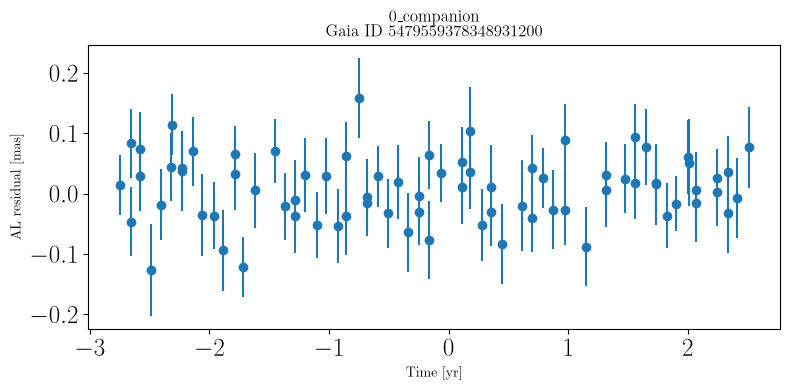

Saved figure: outputs/figures/test_astrometry/residuals_0_companion_5479559378348931200.pdf

Running test simulation for 1_companion_agnostic
Gaia source ID: 5479559378348931200
Gaia DR2 source ID: 5479559378348931200
Number of planets: 1
Saved CSV: outputs/data/test_astrometry/gaia_dr4_sim_1_companion_agnostic_5479559378348931200.csv


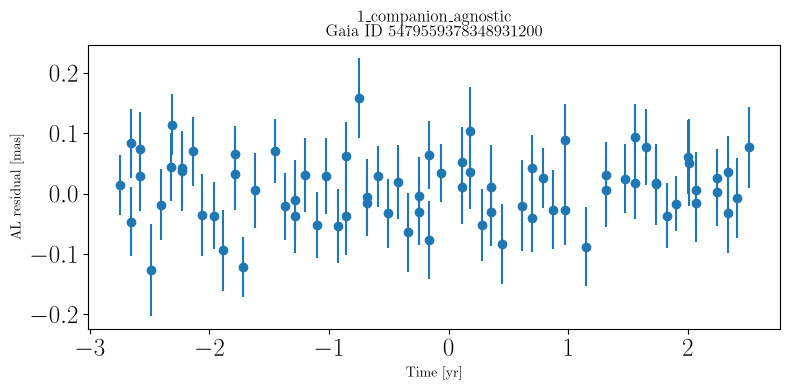

Saved figure: outputs/figures/test_astrometry/residuals_1_companion_agnostic_5479559378348931200.pdf

Running test simulation for 1_companion_detectable
Gaia source ID: 5479559378348931200
Gaia DR2 source ID: 5479559378348931200
Number of planets: 1
Saved CSV: outputs/data/test_astrometry/gaia_dr4_sim_1_companion_detectable_5479559378348931200.csv


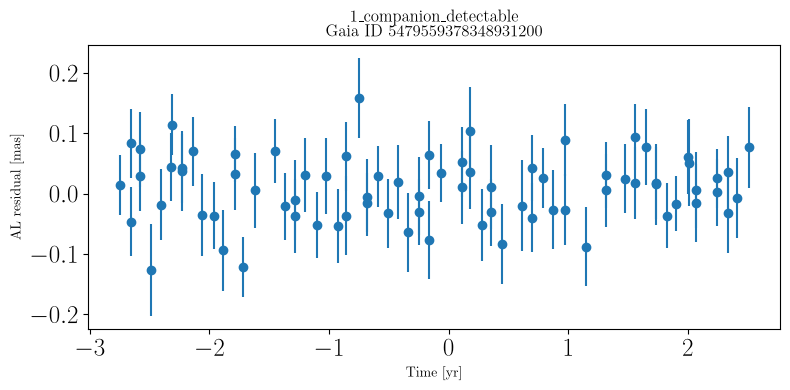

Saved figure: outputs/figures/test_astrometry/residuals_1_companion_detectable_5479559378348931200.pdf

Running test simulation for 2_companion_agnostic
Gaia source ID: 5479559378348931200
Gaia DR2 source ID: 5479559378348931200
Number of planets: 2
Saved CSV: outputs/data/test_astrometry/gaia_dr4_sim_2_companion_agnostic_5479559378348931200.csv


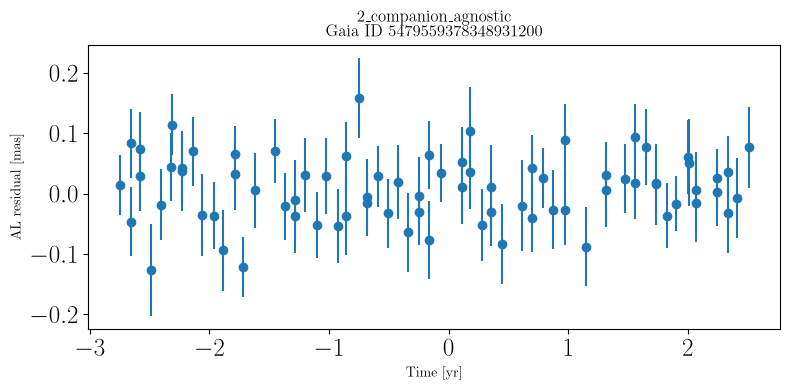

Saved figure: outputs/figures/test_astrometry/residuals_2_companion_agnostic_5479559378348931200.pdf

Running test simulation for 2_companion_detectable
Gaia source ID: 5479559378348931200
Gaia DR2 source ID: 5479559378348931200
Number of planets: 2
Saved CSV: outputs/data/test_astrometry/gaia_dr4_sim_2_companion_detectable_5479559378348931200.csv


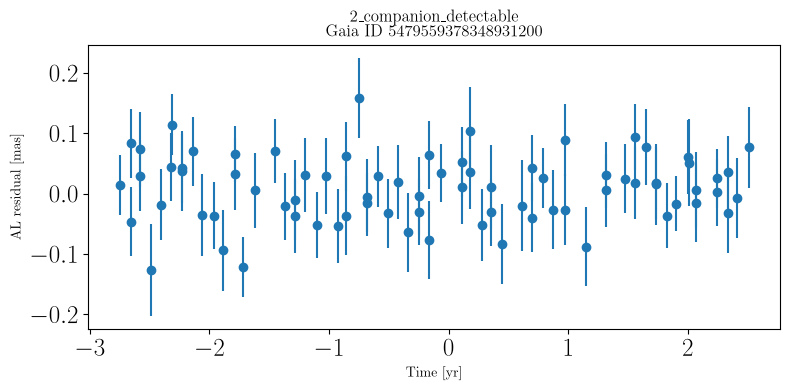

Saved figure: outputs/figures/test_astrometry/residuals_2_companion_detectable_5479559378348931200.pdf


In [9]:
import os
import matplotlib.pyplot as plt


# --------------------------------------------------
# Single-system test for each population
# --------------------------------------------------

sample_scanlaw_dr4_df = sample_scanlaw_dr4_df.copy()
sample_sources_w_mass_radius = sample_sources_w_mass_radius.copy()

sample_scanlaw_dr4_df["gaia_source_id"] = (
    sample_scanlaw_dr4_df["gaia_source_id"]
    .astype("Int64")
    .astype(str)
)

for id_col in ["gaia_source_id", "source_id_dr2"]:
    sample_sources_w_mass_radius[id_col] = (
        sample_sources_w_mass_radius[id_col]
        .astype("Int64")
        .astype(str)
    )


test_populations = {
    "0_companion": systems0_planet,
    "1_companion_agnostic": systems1_planet_nosnrfilter,
    "1_companion_detectable": systems1_planet_snrfilter,
    "2_companion_agnostic": systems2_planet_nosnrfilter,
    "2_companion_detectable": systems2_planet_snrfilter,
}

os.makedirs("outputs/data/test_astrometry/", exist_ok=True)
os.makedirs("outputs/figures/test_astrometry/", exist_ok=True)

test_results = {}

for pop_name, systems in test_populations.items():

    # Take the first system in this population
    system = systems[0]

    gaia_source_id = system["gaia_source_id"]
    source_id_dr2 = system["source_id_dr2"]
    planets = system["planets"]

    print("\n" + "=" * 70)
    print(f"Running test simulation for {pop_name}")
    print(f"Gaia source ID: {gaia_source_id}")
    print(f"Gaia DR2 source ID: {source_id_dr2}")
    print(f"Number of planets: {len(planets)}")
    print("=" * 70)

    output_df, result, source_row, scan_rows = prepare_and_simulate_gaia_astrometry(
        gaia_source_id=gaia_source_id,
        source_id_dr2=source_id_dr2,
        sample_scanlaw_dr4_df=sample_scanlaw_dr4_df,
        sample_sources_df=sample_sources_w_mass_radius,
        planets=planets,
    )

    # Store outputs in memory
    test_results[pop_name] = {
        "gaia_source_id": gaia_source_id,
        "source_id_dr2": source_id_dr2,
        "planets": planets,
        "output_df": output_df,
        "result": result,
        "source_row": source_row,
        "scan_rows": scan_rows,
    }

    # Save simulated Gaia-like epoch astrometry
    csv_path = f"outputs/data/test_astrometry/gaia_dr4_sim_{pop_name}_{gaia_source_id}.csv"
    output_df.to_csv(csv_path, index=False)

    print(f"Saved CSV: {csv_path}")

    # Quick residual plot
    plt.figure(figsize=(8, 4))
    plt.errorbar(
        result["t"],
        result["al_true"] - result["al_obs"],
        marker="o",
        ls="",
        yerr=result["sigma_UEVA"],
    )
    plt.xlabel("Time [yr]")
    plt.ylabel("AL residual [mas]")
    plt.title(f"{pop_name}\nGaia ID {gaia_source_id}")
    plt.tight_layout()

    fig_path = f"outputs/figures/test_astrometry/residuals_{pop_name}_{gaia_source_id}.pdf"
    plt.savefig(fig_path)
    plt.show()

    print(f"Saved figure: {fig_path}")

    # Your existing diagnostic plot
    #plot_residuals_with_errors(result)

In [10]:
import os
import pandas as pd
from tqdm.auto import tqdm


def simulate_all_populations_astrometry(
    populations,
    sample_scanlaw_dr4_df,
    sample_sources_df,
    output_dir="outputs/data/simulated_astrometry/",
    injected_solutions_path="outputs/data/injected_solutions_all.csv",
    seed=ASTROMETRY_MASTER_SEED,
):
    os.makedirs(output_dir, exist_ok=True)

    # Normalize identifiers without passing through floating point.
    sample_scanlaw_dr4_df = sample_scanlaw_dr4_df.copy()
    sample_sources_df = sample_sources_df.copy()

    sample_scanlaw_dr4_df["gaia_source_id"] = (
        sample_scanlaw_dr4_df["gaia_source_id"].astype("Int64").astype(str)
    )
    for id_col in ["gaia_source_id", "source_id_dr2"]:
        sample_sources_df[id_col] = (
            sample_sources_df[id_col].astype("Int64").astype(str)
        )

    # A Gaia source can have multiple DR2 cross-matches. The pair, not either
    # identifier alone, is the source-row key and must be unique.
    source_key = ["gaia_source_id", "source_id_dr2"]
    duplicate_source_keys = sample_sources_df.duplicated(source_key, keep=False)
    if duplicate_source_keys.any():
        duplicate_keys = sample_sources_df.loc[duplicate_source_keys, source_key]
        raise ValueError(
            f"sample_sources_df has {len(duplicate_keys)} rows with duplicate "
            f"(gaia_source_id, source_id_dr2) keys"
        )

    injected_rows = []

    for pop_name, systems in populations.items():

        pop_output_dir = os.path.join(output_dir, pop_name)
        os.makedirs(pop_output_dir, exist_ok=True)

        print("\n" + "=" * 80)
        print(f"Running population: {pop_name}")
        print(f"N systems: {len(systems)}")
        print("=" * 80)

        for idx, system in enumerate(tqdm(systems, desc=pop_name)):

            gaia_source_id = str(system["gaia_source_id"])
            source_id_dr2 = str(system["source_id_dr2"])
            planets = system["planets"]

            system_id = f"{pop_name}_SYS_{idx:07d}"
            system_seed = stable_system_seed(seed, system_id)

            output_file = f"{system_id}.csv"
            output_path = os.path.join(pop_output_dir, output_file)

            try:
                output_df, result, source_row, scan_rows = prepare_and_simulate_gaia_astrometry(
                    gaia_source_id=gaia_source_id,
                    source_id_dr2=source_id_dr2,
                    sample_scanlaw_dr4_df=sample_scanlaw_dr4_df,
                    sample_sources_df=sample_sources_df,
                    planets=planets,
                    seed=system_seed,
                )

                output_df["system_id"] = system_id
                output_df["gaia_source_id"] = gaia_source_id
                output_df["source_id_dr2"] = source_id_dr2
                output_df["system_seed"] = system_seed
                output_df.to_csv(output_path, index=False)

                base_row = {
                    "system_id": system_id,
                    "filename": output_file,
                    "filepath": output_path,
                    "population": pop_name,
                    "gaia_source_id": gaia_source_id,
                    "source_id_dr2": source_id_dr2,
                    "master_seed": int(seed),
                    "system_seed": system_seed,
                    "noise_seed": result["noise_seed"],
                    "observation_seed": result["observation_seed"],
                    "n_planets": len(planets),

                    "parallax_mas": source_row["parallax"],
                    "pmra_mas_yr": source_row["pmra_dr3"],
                    "pmdec_mas_yr": source_row["pmdec_dr3"],
                    "mass_st_msun": source_row["mass_interp"],
                    "radius_st_rsun": source_row["radius_interp"],
                }

                for pidx, planet in enumerate(planets, start=1):
                    base_row[f"a_{pidx}_au"] = planet["a"]
                    base_row[f"e_{pidx}"] = planet["e"]
                    base_row[f"i_{pidx}_rad"] = planet["i"]
                    base_row[f"Omega_{pidx}_rad"] = planet["Omega"]
                    base_row[f"omega_{pidx}_rad"] = planet["omega"]
                    base_row[f"M0_{pidx}_rad"] = planet["M0"]
                    base_row[f"Mp_{pidx}_msun"] = planet["Mp_sun"]
                    # carried-through detectability (normalized to _1/_2)
                    base_row[f"period_{pidx}"] = planet.get("period")
                    base_row[f"alpha_{pidx}_mas"] = planet.get("alpha_mas")
                    base_row[f"snr_single_{pidx}"] = planet.get("snr_single")
                    base_row[f"snr_eff_{pidx}"] = planet.get("snr_eff")
                    base_row[f"snr_total_{pidx}"] = planet.get("snr_total")

                # carried-through per-system catalog columns
                for _col in ("sigma_single_mas", "n_transits_dr4", "generation_seed",
                             "P_ratio", "near_2_1", "near_3_2", "near_resonance",
                             "coplanar"):
                    if _col in system:
                        base_row[_col] = system[_col]

                injected_rows.append(base_row)

            except Exception as err:
                # All systems are expected to simulate successfully; on the rare
                # failure, log and skip rather than emit a partial catalog row.
                tqdm.write(f"FAILED {system_id}: {err}")
                continue

    injected_solutions_df = pd.DataFrame(injected_rows)
    injected_solutions_df.to_csv(injected_solutions_path, index=False)

    print("\nDone.")
    print(f"Saved injected solutions table to:\n{injected_solutions_path}")

    return injected_solutions_df

/Users/daniel/opt/anaconda3/envs/epochalypse-arm64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
populations = {
    "0_companion": systems0_planet,
    "1_companion_agnostic": systems1_planet_nosnrfilter,
    "1_companion_detectable": systems1_planet_snrfilter,
    "2_companion_agnostic": systems2_planet_nosnrfilter,
    "2_companion_detectable": systems2_planet_snrfilter,
}

injected_solutions_df = simulate_all_populations_astrometry(
    populations=populations,
    sample_scanlaw_dr4_df=sample_scanlaw_dr4_df,
    sample_sources_df=sample_sources_w_mass_radius,
)


Running population: 0_companion
N systems: 10655


0_companion: 100%|██████████| 10655/10655 [02:15<00:00, 78.74it/s] 



Running population: 1_companion_agnostic
N systems: 10655


1_companion_agnostic: 100%|██████████| 10655/10655 [02:18<00:00, 77.13it/s] 



Running population: 1_companion_detectable
N systems: 10654


...


Running population: 2_companion_agnostic
N systems: 10655


2_companion_agnostic: 100%|██████████| 10655/10655 [01:53<00:00, 93.57it/s] 



Running population: 2_companion_detectable
N systems: 10653


2_companion_detectable: 100%|██████████| 10653/10653 [01:55<00:00, 92.09it/s]



Done.
Saved injected solutions table to:
outputs/data/injected_solutions_all.csv


In [12]:
import h5py
import numpy as np
from pathlib import Path


def _dataframe_to_structured_array(df):
    """Convert a DataFrame to a numpy structured array suitable for h5py.

    Object/string columns are stored as variable-length UTF-8 strings (NaN ->
    empty string); all other columns keep their native numpy dtype.
    """
    str_dt = h5py.string_dtype(encoding="utf-8")
    dtypes = []
    columns = {}
    for name in df.columns:
        col = df[name]
        if col.dtype == object or pd.api.types.is_string_dtype(col):
            values = col.where(col.notna(), "").astype(str).to_numpy()
            dtypes.append((name, str_dt))
        else:
            values = col.to_numpy()
            dtypes.append((name, values.dtype))
        columns[name] = values

    arr = np.empty(len(df), dtype=dtypes)
    for name in df.columns:
        arr[name] = columns[name]
    return arr


def export_populations_to_truths_systems_hdf5(
    input_dir="outputs/data/simulated_astrometry",
    output_dir="outputs/data",
    injected_solutions_path="outputs/data/injected_solutions_all.csv",
    populations=None,
    overwrite=False,
    compression="gzip",
):
    """Write one HDF5 file per population in a /truths + /systems layout.

    Each file (simulated_astrometry_<population>_systems.h5) contains:

        /truths                 one row per system (the injected-solution
                                truth table for that population)
        /systems/<idx>/epochs   epoch table for the system at /truths row <idx>

    The integer <idx> is the row position in /truths, so the truth values and
    a system's epoch data line up by position: read the truths for system 1
    from /truths[1] and its epochs from /systems/1/epochs.
    """
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    injected = pd.read_csv(
        injected_solutions_path,
        dtype={"gaia_source_id": str, "source_id_dr2": str},
        low_memory=False,
    )

    available = sorted(injected["population"].unique())
    selected = available if populations is None else list(populations)
    unknown = sorted(set(selected).difference(available))
    if unknown:
        raise ValueError(f"Unknown populations: {unknown}; available: {available}")

    written = []
    for population in selected:
        truths = (
            injected.loc[injected["population"] == population]
            .reset_index(drop=True)
        )

        output_path = output_dir / f"simulated_astrometry_{population}_systems.h5"
        if output_path.exists() and not overwrite:
            raise FileExistsError(
                f"{output_path} already exists; pass overwrite=True to replace it"
            )

        temporary_path = output_path.with_suffix(output_path.suffix + ".tmp")
        if temporary_path.exists():
            temporary_path.unlink()

        n_with_epochs = 0
        try:
            with h5py.File(temporary_path, "w") as f:
                f.create_dataset(
                    "truths",
                    data=_dataframe_to_structured_array(truths),
                    compression=compression,
                )
                f["truths"].attrs["population"] = population
                f["truths"].attrs["n_systems"] = len(truths)

                systems = f.create_group("systems")
                for idx, row in truths.iterrows():
                    group = systems.create_group(str(idx))
                    group.attrs["system_id"] = str(row["system_id"])
                    group.attrs["gaia_source_id"] = str(row["gaia_source_id"])
                    group.attrs["source_id_dr2"] = str(row["source_id_dr2"])

                    csv_path = Path(row["filepath"])
                    if csv_path.exists():
                        epochs = pd.read_csv(
                            csv_path,
                            dtype={"gaia_source_id": str, "source_id_dr2": str},
                        )
                        group.create_dataset(
                            "epochs",
                            data=_dataframe_to_structured_array(epochs),
                            compression=compression,
                        )
                        n_with_epochs += 1

                    if (idx + 1) % 500 == 0 or (idx + 1) == len(truths):
                        print(
                            f"{population}: {idx + 1}/{len(truths)} systems, "
                            f"{n_with_epochs} with epochs",
                            end="\r",
                        )

            temporary_path.replace(output_path)
        except Exception:
            if temporary_path.exists():
                temporary_path.unlink()
            raise

        print()
        size_mib = output_path.stat().st_size / 1024**2
        print(f"Saved {output_path} ({size_mib:.1f} MiB)")
        written.append({
            "population": population,
            "path": str(output_path),
            "n_systems": len(truths),
            "n_with_epochs": n_with_epochs,
        })

    return pd.DataFrame(written)


# Run after all simulations have finished and injected_solutions_all.csv exists:
systems_files = export_populations_to_truths_systems_hdf5(overwrite=True)
systems_files


0_companion: 10655/10655 systems, 10655 with epochs
Saved outputs/data/simulated_astrometry_0_companion_systems.h5 (237.9 MiB)
1_companion_agnostic: 10655/10655 systems, 10655 with epochs
Saved outputs/data/simulated_astrometry_1_companion_agnostic_systems.h5 (247.8 MiB)
1_companion_detectable: 10654/10654 systems, 10654 with epochs
Saved outputs/data/simulated_astrometry_1_companion_detectable_systems.h5 (255.0 MiB)
2_companion_agnostic: 10655/10655 systems, 10655 with epochs
Saved outputs/data/simulated_astrometry_2_companion_agnostic_systems.h5 (249.1 MiB)
2_companion_detectable: 10653/10653 systems, 10653 with epochs
Saved outputs/data/simulated_astrometry_2_companion_detectable_systems.h5 (256.3 MiB)


,population,path,n_systems,n_with_epochs
0,0_companion,outputs/data/simulated_astrometry_0_companion_...,10655,10655
1,1_companion_agnostic,outputs/data/simulated_astrometry_1_companion_...,10655,10655
2,1_companion_detectable,outputs/data/simulated_astrometry_1_companion_...,10654,10654
3,2_companion_agnostic,outputs/data/simulated_astrometry_2_companion_...,10655,10655
4,2_companion_detectable,outputs/data/simulated_astrometry_2_companion_...,10653,10653


In [13]:
# Example reads for the /truths + /systems layout:
with h5py.File("outputs/data/simulated_astrometry_1_companion_detectable_systems.h5", "r") as f:
    print(list(f.keys()))                 # ['systems', 'truths']
    print("n_systems:", f["truths"].attrs["n_systems"])

    # Truth values for system 1 (row 1 of /truths)
    truths_row1 = f["truths"][1]
    print(truths_row1)

    # Epoch table for the same system
    epochs1 = pd.DataFrame(f["systems/1/epochs"][:])
    # Decode any variable-length string columns from bytes to str
    for col in epochs1.columns:
        if epochs1[col].dtype == object:
            epochs1[col] = epochs1[col].str.decode("utf-8")

epochs1.head()


['systems', 'truths']
n_systems: 10654
(b'1_companion_detectable_SYS_0000001', b'1_companion_detectable_SYS_0000001.csv', b'outputs/data/simulated_astrometry/1_companion_detectable/1_companion_detectable_SYS_0000001.csv', b'1_companion_detectable', b'5481069145252396928', b'5481069145252396928', 45, 3717689753, 4001174858, 3615455816, 1, 10.807500209726031, 35.160134972388164, -79.85848381457424, 0.3644776846110203, 0.3576313876127224, 3.94832188011783, 0.4639191284260638, 1.0149450296611873, 3.7002759273010626, 4.706032230418257, 4.464226138351842, 0.0538093090653744, 12.130588749847025, 5.489309102670212, 83.2794651741875, 12.651335589964662, 114.56271627895497, 0.0659143174273365, 82.0, 1981677229.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, b'', b'', b'', b'')


,obs_time_tcb,centroid_pos_al,centroid_pos_error_al,parallax_factor_al,scan_pos_angle,field_of_view,gaia_source_id,source_id_dr2,system_id,system_seed
0,2.456933e+06,-218.743846,0.071930,0.714134,2.445947,FoVF,5481069145252396928,5481069145252396928,1_companion_detectable_SYS_0000001,3717689753
1,2.456996e+06,-145.205312,0.079030,0.700487,-2.736307,FoVP,5481069145252396928,5481069145252396928,1_companion_detectable_SYS_0000001,3717689753
2,2.456996e+06,-144.883639,0.072619,0.700131,-2.734517,FoVF,5481069145252396928,5481069145252396928,1_companion_detectable_SYS_0000001,3717689753
3,2.457029e+06,202.299180,0.063819,-0.698125,-0.588836,FoVP,5481069145252396928,5481069145252396928,1_companion_detectable_SYS_0000001,3717689753
4,2.457029e+06,202.161812,0.071003,-0.698572,-0.586870,FoVF,5481069145252396928,5481069145252396928,1_companion_detectable_SYS_0000001,3717689753
